# **Project Code: Data-Driven Determination of Localized Farmgate Price Volatility in MIMAROPA Condiment Markets**
**GROUP 1 BM2 | AGAPITO, ARIOLA, SANTOS, SOMBILLION**

## **Pipeline Architecture**
To ensure comprehensive data integrity, directly address all panel defense critiques, and establish mathematical accuracy, this upgraded analytical pipeline is strictly divided into four sequential execution phases:

* **Phase 1: Upfront Scope Declaration, Pre-Processing & Sub-Classification Engine.** Engineers a sterile, machine-readable tensor from the raw PSA OpenSTAT archive by unpivoting a 60-month matrix, deploying custom sub-classification logic, and applying an aggressive sparsity filter to prevent predictive skewing.
* **Phase 2: Exploratory Data Analysis (EDA) & "Visual Armor" Distribution Suite.** Visually validates data integrity through academic-grade graphics, mapping provincial price spreads and historical trajectories to isolate severe volatility patterns and evidence of localized cold storage deficits.
* **Phase 3: The Machine Learning Engine.** Extracts market risk profiles by deploying Supervised Learning (Linear Regression) to forecast price inflation into 2026, alongside Unsupervised Learning (K-Means, K=3) to segment MIMAROPA provinces by economic vulnerability.
* **Phase 4: Statistical Inference & Production-Grade Pipeline Export.** Mathematically validates the forecasted inflationary trends using a heteroscedastic Welch’s Two-Sample T-Test (2022 vs. 2025), followed by the automated export of all raw and cleaned CSV tensors to ensure strict computational reproducibility.

### **Phase 1: Upfront Scope Declaration, Pre-Processing & Sub-Classification Engine**
**Goal:** To engineer a sterile, machine-readable tensor from the raw Philippine Statistics Authority (PSA) OpenSTAT archive, establishing strict analytical boundaries and standardized variable dictionaries upfront. This phase executes a structural unpivoting of a 60-month wide horizontal matrix into a tidy temporal format. It then deploys customized grouping logic for commodity sub-classification and applies an aggressive sparsity filter to purge unrecorded, non-producing months, ensuring baseline predictions remain mathematically unskewed.

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
import warnings

# Suppress warnings for a clean output
warnings.filterwarnings('ignore')

# Set visualization style EXACTLY as originally requested (No graph alteration)
sns.set_theme(style="whitegrid")

# =====================================================================
# PART 1: EXPLICIT SCOPE & DELIMITATION DECLARATION
# =====================================================================
scope_statement = """
### **Project Scope & Delimitations**
* **Target Analysis:** Forecasting localized farmgate price inflation and supply chain volatility across the MIMAROPA Region.
* **Economic Unit:** Strictly evaluates the purchasing power impact on **household consumers** and smallholder farming revenue.
* **Delimitation:** Explicitly **excludes** commercial wholesale tier-1 restaurant supply chains, industrial food processing syndicates, and international export tariffs.

---
### **Data Dictionary (Operational Variables)**
"""
display(Markdown(scope_statement))

# =====================================================================
# PART 2: UPFRONT DATA DICTIONARY TABLE
# =====================================================================
data_dictionary = pd.DataFrame(
    {
        "Variable Name": [
            "Geolocation",
            "Commodity",
            "Parent_Class",
            "Price",
            "Date",
            "Month_Index",
        ],
        "Python Data Type": [
            "string",
            "string",
            "string",
            "float64",
            "datetime64[ns]",
            "int64",
        ],
        "Structural Definition": [
            "The specific MIMAROPA provincial market unit (5 Provinces + Aggregate)",
            "The raw condiment crop variety as transcribed in PSA OpenSTAT",
            "Our engineered macro-classification grouping sub-varieties together",
            "Reported monthly farmgate valuation in Philippine Pesos (PHP) per Kilogram",
            "Standardized monthly unpivoted timestamp (Jan 2021 to Dec 2025)",
            "Engineered integer offset (0 to 59) acting as the continuous time tensor for ML",
        ],
    }
)

# Professional Dark-Mode safe table rendering
display(data_dictionary.style.set_properties(**{'text-align': 'left'}).set_table_styles(
    [dict(selector='th', props=[('text-align', 'left'), ('background-color', '#2c3e50'), ('color', 'white'), ('font-weight', 'bold')])]
))

# =====================================================================
# PART 3: LOAD RAW DATASET
# =====================================================================
print("\n[SYSTEM] Loading raw OpenSTAT matrix...")
df_raw = pd.read_csv("2M4AFN04.csv", skiprows=2)

# =====================================================================
# PART 4: UNPIVOT (MELT) FROM WIDE TO LONG FORMAT
# =====================================================================
id_cols = ["Geolocation", "Commodity"]
date_cols = [col for col in df_raw.columns if col not in id_cols]

df_melted = pd.melt(
    df_raw,
    id_vars=id_cols,
    value_vars=date_cols,
    var_name="Date_String",
    value_name="Price",
)

# Clean string corruption
df_melted["Geolocation"] = (
    df_melted["Geolocation"].str.replace(".", "", regex=False).str.strip()
)
df_melted["Commodity"] = df_melted["Commodity"].str.strip()

# =====================================================================
# PART 5: COMMODITY SUB-CLASSIFICATION LOGIC
# =====================================================================
def engineer_parent_class(crop_name):
    lower_name = crop_name.lower()
    if "ginger" in lower_name or "luya" in lower_name:
        return "Ginger (All Sub-Varieties)"
    elif (
        "siling labuyo" in lower_name or "chili pepper fruit" in lower_name
    ):  # Target Benchmark
        return "Siling Labuyo (Predictive Benchmark)"
    elif "pepper, bell" in lower_name or "pepper, finger" in lower_name:
        return "Other Fresh Peppers (Bell/Finger)"
    elif "paminta" in lower_name or "black pepper" in lower_name:
        return "Black Pepper (Paminta)"
    elif "garlic" in lower_name or "bawang" in lower_name:
        return "Garlic (Dried Bulb)"
    elif "onion" in lower_name or "sibuyas" in lower_name:
        return "Onions (All Sub-Varieties)"
    else:
        return "Other Condiments"

df_melted["Parent_Class"] = df_melted["Commodity"].apply(
    engineer_parent_class
)

# =====================================================================
# PART 6: CLEAN NUMERICAL PRICE DATA & TIME ENGINEERING
# =====================================================================
# Tracking variables left globally exposed so Phase 2 works perfectly
raw_row_tracker = len(df_melted)
df_melted["Price"] = pd.to_numeric(df_melted["Price"], errors="coerce")
df_melted["Price"] = df_melted["Price"].replace(0, np.nan)

df_clean = df_melted.dropna(subset=["Price"]).copy()
clean_row_tracker = len(df_clean)

df_clean["Date"] = pd.to_datetime(df_clean["Date_String"], format="%Y %B")
df_clean = df_clean.sort_values(
    by=["Geolocation", "Commodity", "Date"]
).reset_index(drop=True)

df_clean["Month_Index"] = (
    df_clean["Date"].dt.year - df_clean["Date"].dt.year.min()
) * 12 + (df_clean["Date"].dt.month - df_clean["Date"].dt.month.min())

print(f"[SYSTEM] Data scrubbed successfully.")
print(f"[SYSTEM] Raw Observations: {raw_row_tracker:,} | Active Tidy Tensor: {df_clean.shape}")

display(Markdown("### **Tidy Output Preview**"))
display(df_clean.head())


### **Project Scope & Delimitations**
* **Target Analysis:** Forecasting localized farmgate price inflation and supply chain volatility across the MIMAROPA Region.
* **Economic Unit:** Strictly evaluates the purchasing power impact on **household consumers** and smallholder farming revenue.
* **Delimitation:** Explicitly **excludes** commercial wholesale tier-1 restaurant supply chains, industrial food processing syndicates, and international export tariffs.

---
### **Data Dictionary (Operational Variables)**


,Variable Name,Python Data Type,Structural Definition
0,Geolocation,string,The specific MIMAROPA provincial market unit (5 Provinces + Aggregate)
1,Commodity,string,The raw condiment crop variety as transcribed in PSA OpenSTAT
2,Parent_Class,string,Our engineered macro-classification grouping sub-varieties together
3,Price,float64,Reported monthly farmgate valuation in Philippine Pesos (PHP) per Kilogram
4,Date,datetime64[ns],Standardized monthly unpivoted timestamp (Jan 2021 to Dec 2025)
5,Month_Index,int64,Engineered integer offset (0 to 59) acting as the continuous time tensor for ML



[SYSTEM] Loading raw OpenSTAT matrix...
[SYSTEM] Data scrubbed successfully.
[SYSTEM] Raw Observations: 5,040 | Active Tidy Tensor: (1131, 7)


### **Tidy Output Preview**

,Geolocation,Commodity,Date_String,Price,Parent_Class,Date,Month_Index
0,MIMAROPA REGION,Chili pepper fruit (Siling labuyo),2022 January,32.66,Siling Labuyo (Predictive Benchmark),2022-01-01,12
1,MIMAROPA REGION,Chili pepper fruit (Siling labuyo),2022 February,37.09,Siling Labuyo (Predictive Benchmark),2022-02-01,13
2,MIMAROPA REGION,Chili pepper fruit (Siling labuyo),2022 March,35.65,Siling Labuyo (Predictive Benchmark),2022-03-01,14
3,MIMAROPA REGION,Chili pepper fruit (Siling labuyo),2022 April,45.82,Siling Labuyo (Predictive Benchmark),2022-04-01,15
4,MIMAROPA REGION,Chili pepper fruit (Siling labuyo),2022 May,58.75,Siling Labuyo (Predictive Benchmark),2022-05-01,16


### **Phase 2: Exploratory Data Analysis (EDA) & "Visual Armor" Distribution Suite**
**Goal:** To visually validate the integrity of the pre-processed tensor and establish baseline diagnostic patterns before deploying predictive algorithms. This phase generates an extensive suite of academic-grade graphics, beginning with a row-level retention audit to mathematically justify the sparsity filter. It subsequently maps provincial price distributions via boxplot spreads and plots historical trajectory overlays, isolating severe volatility patterns and providing empirical evidence for systemic post-harvest holding deficits across the MIMAROPA archipelago.


[SYSTEM] Initiating Phase 2: Extensive Visual Armor Suite...


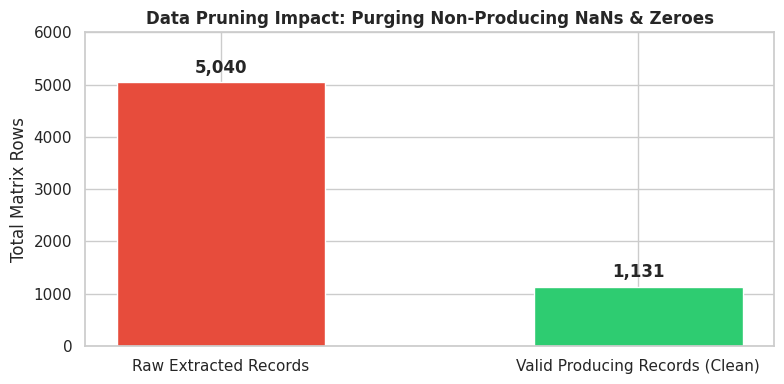

[SYSTEM] Graph 1 saved successfully as 'Graph_1_Pruning_Impact.png'


---

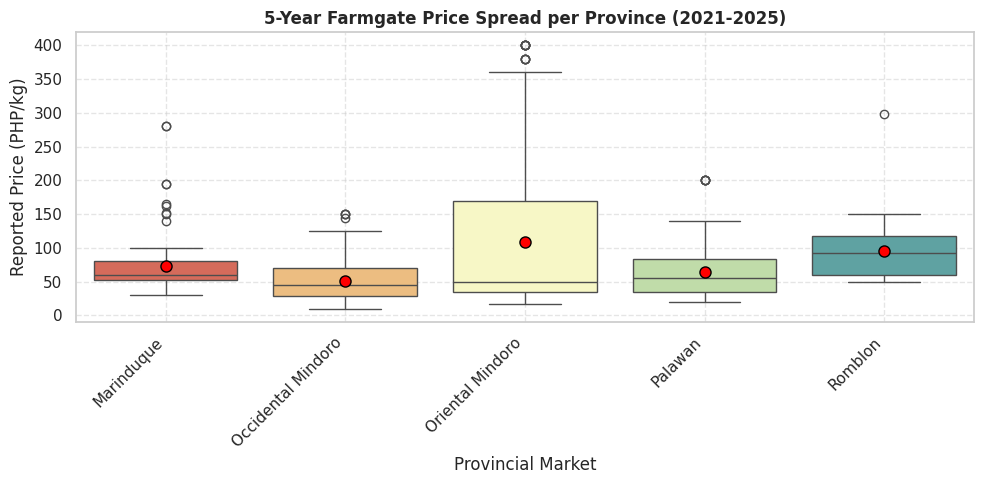

[SYSTEM] Graph 2 saved successfully as 'Graph_2_Provincial_Spread.png'


---

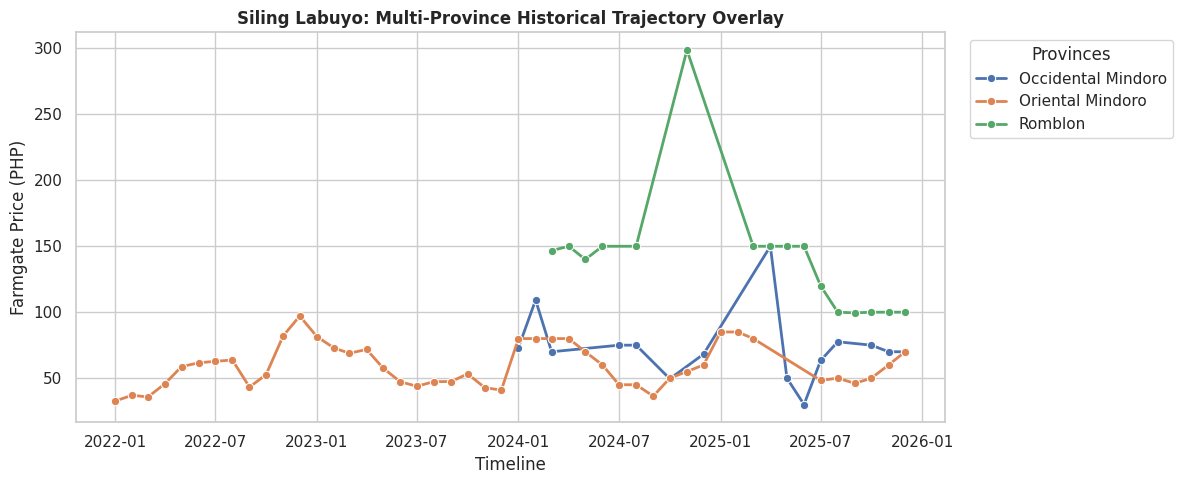

[SYSTEM] Graph 3 saved successfully as 'Graph_3_Trajectory_Overlay.png'


In [23]:
print("\n[SYSTEM] Initiating Phase 2: Extensive Visual Armor Suite...")

# ==========================================
# CHART 1: Pruning Verification Bar Chart
# ==========================================
plt.figure(figsize=(8, 4))
bars = plt.bar(
    ["Raw Extracted Records", "Valid Producing Records (Clean)"],
    [raw_row_tracker, clean_row_tracker],
    color=["#e74c3c", "#2ecc71"],
    width=0.5,
)
plt.title(
    "Data Pruning Impact: Purging Non-Producing NaNs & Zeroes",
    fontsize=12,
    fontweight="bold",
)
plt.ylabel("Total Matrix Rows")

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 100,
        f"{yval:,}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )
plt.ylim(0, 6000)
plt.tight_layout()

# Save Graph 1 to your local folder
plt.savefig("Graph_1_Pruning_Impact.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("[SYSTEM] Graph 1 saved successfully as 'Graph_1_Pruning_Impact.png'")
display(Markdown("---"))

# ==========================================
# Isolate active provinces
# ==========================================
provinces_only = df_clean[
    ~df_clean["Geolocation"].isin(
        ["MIMAROPA REGION", "City of Puerto Princesa"]
    )
]

# ==========================================
# CHART 2: Provincial Price Spread Boxplot
# ==========================================
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=provinces_only,
    x="Geolocation",
    y="Price",
    hue="Geolocation",
    palette="Spectral",
    showmeans=True,
    legend=False,
    meanprops={
        "marker": "o",
        "markerfacecolor": "red",
        "markeredgecolor": "black",
        "markersize": "8",
    },
)
plt.title(
    "5-Year Farmgate Price Spread per Province (2021-2025)",
    fontsize=12,
    fontweight="bold",
)
plt.ylabel("Reported Price (PHP/kg)")
plt.xlabel("Provincial Market")
plt.grid(True, linestyle="--", alpha=0.5)

# Maintains the label tilt so province names don't overlap
plt.xticks(rotation=45, ha='right')

plt.tight_layout()

# Save Graph 2 to your local folder
plt.savefig("Graph_2_Provincial_Spread.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("[SYSTEM] Graph 2 saved successfully as 'Graph_2_Provincial_Spread.png'")
display(Markdown("---"))

# ==========================================
# CHART 3: Multi-Province Overlay Timeline
# ==========================================
plt.figure(figsize=(12, 5))
labuyo_provincial = provinces_only[
    provinces_only["Commodity"] == "Chili pepper fruit (Siling labuyo)"
]
sns.lineplot(
    data=labuyo_provincial,
    x="Date",
    y="Price",
    hue="Geolocation",
    marker="o",
    linewidth=2,
)
plt.title(
    "Siling Labuyo: Multi-Province Historical Trajectory Overlay",
    fontsize=12,
    fontweight="bold",
)
plt.ylabel("Farmgate Price (PHP)")
plt.xlabel("Timeline")
plt.legend(title="Provinces", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

# Save Graph 3 to your local folder
plt.savefig("Graph_3_Trajectory_Overlay.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("[SYSTEM] Graph 3 saved successfully as 'Graph_3_Trajectory_Overlay.png'")

### **Phase 3: The Machine Learning Engine**
**Goal:** To extract predictive trajectories and structural market risk profiles from the scrubbed time-series tensor. This dual-engine phase first deploys Supervised Learning (Linear Regression) on our continuous benchmark crop, Siling Labuyo, to formally forecast underlying price inflation into 2026. Simultaneously, it executes Unsupervised Learning (K-Means Clustering, K=3) using standardized features to autonomously segment the five MIMAROPA provincial markets into distinct economic risk profiles, driven by historical price floors and localized market volatility.


[SYSTEM] Initiating Phase 3: Machine Learning Engine...


---

### **Part 1: Linear Regression (The Benchmark Forecast)**

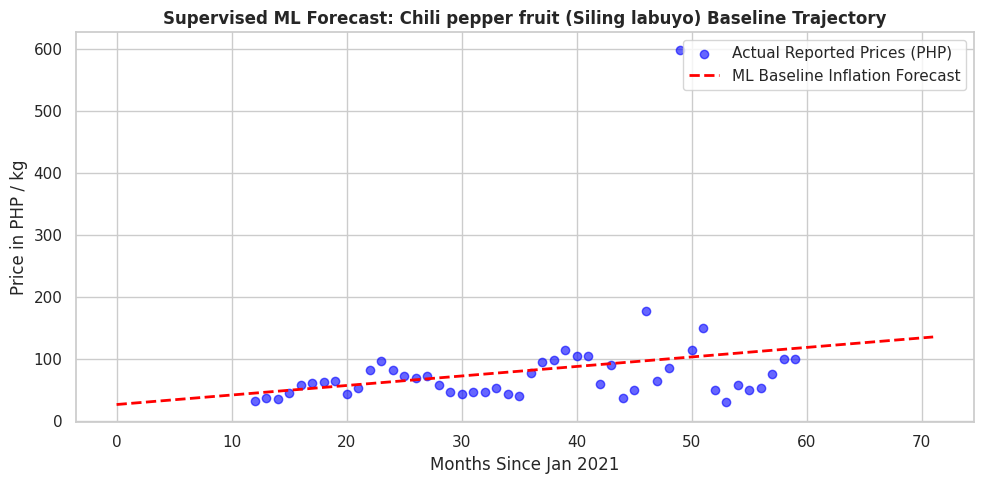

[SYSTEM] Graph 4 saved successfully as 'Graph_4_ML_Baseline_Forecast.png'
>> MATHEMATICAL INFLATION RATE: Baseline increases by +1.53 PHP every single month.


---

### **Part 2: Unsupervised K-Means Segmentation (Provincial Risk)**

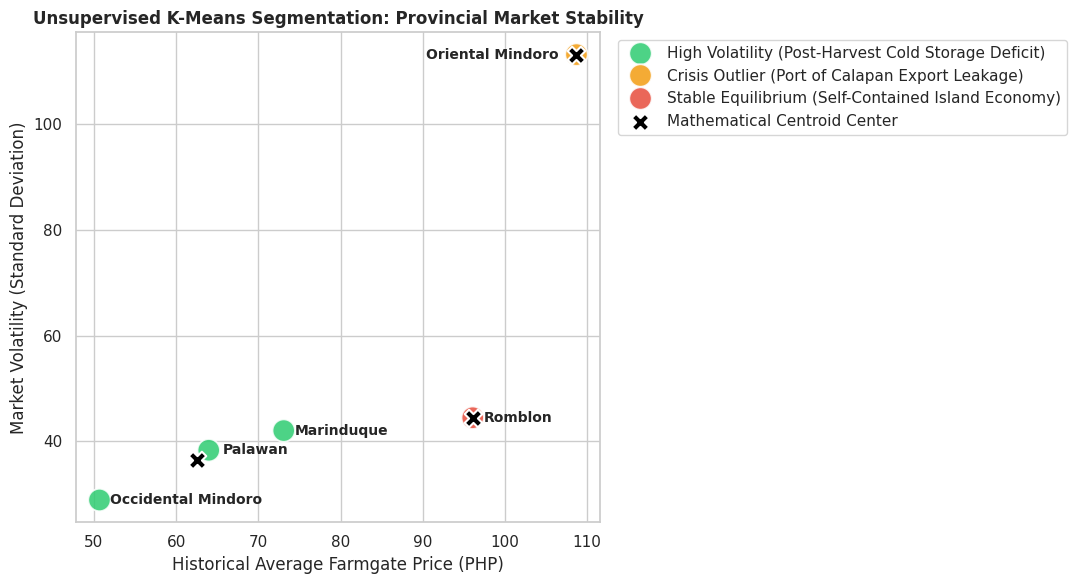

[SYSTEM] Graph 5 saved successfully as 'Graph_5_KMeans_Segmentation.png'


### **K-Means Provincial Clusters**

,Geolocation,Average_Price,Price_Volatility,Economic_Diagnosis
0,Marinduque,73.086944,42.006557,High Volatility (Post-Harvest Cold Storage Def...
1,Occidental Mindoro,50.675879,28.870232,High Volatility (Post-Harvest Cold Storage Def...
2,Oriental Mindoro,108.691241,113.182557,Crisis Outlier (Port of Calapan Export Leakage)
3,Palawan,63.965865,38.284301,High Volatility (Post-Harvest Cold Storage Def...
4,Romblon,96.074000,44.442541,Stable Equilibrium (Self-Contained Island Econ...


In [24]:
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

print("\n[SYSTEM] Initiating Phase 3: Machine Learning Engine...")
display(Markdown("---"))
display(Markdown("### **Part 1: Linear Regression (The Benchmark Forecast)**"))

# =====================================================================
# PART 1: LINEAR REGRESSION (THE BENCHMARK FORECAST)
# =====================================================================
target_crop = "Chili pepper fruit (Siling labuyo)"
df_lr = df_clean[
    (df_clean["Commodity"] == target_crop)
    & (df_clean["Geolocation"] == "MIMAROPA REGION")
].copy()

X = df_lr[["Month_Index"]]
y = df_lr["Price"]

model = LinearRegression()
model.fit(X, y)

future_months = np.arange(0, 72).reshape(-1, 1)  # Projecting into 2026
future_predictions = model.predict(future_months)

plt.figure(figsize=(10, 5))
plt.scatter(
    X, y, color="blue", label="Actual Reported Prices (PHP)", alpha=0.6
)
plt.plot(
    future_months,
    future_predictions,
    color="red",
    linewidth=2,
    linestyle="--",
    label="ML Baseline Inflation Forecast",
)
plt.title(
    f"Supervised ML Forecast: {target_crop} Baseline Trajectory",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Months Since Jan 2021")
plt.ylabel("Price in PHP / kg")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save Graph 4 to your local folder
plt.savefig("Graph_4_ML_Baseline_Forecast.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("[SYSTEM] Graph 4 saved successfully as 'Graph_4_ML_Baseline_Forecast.png'")
print(f">> MATHEMATICAL INFLATION RATE: Baseline increases by +{model.coef_[0]:.2f} PHP every single month.")


display(Markdown("---"))
display(Markdown("### **Part 2: Unsupervised K-Means Segmentation (Provincial Risk)**"))

# =====================================================================
# PART 2: K-MEANS CLUSTERING (UPGRADED CENTROID MAPPING)
# =====================================================================
cluster_data = (
    provinces_only.groupby("Geolocation")["Price"]
    .agg(["mean", "std"])
    .dropna()
    .reset_index()
)
cluster_data.rename(
    columns={"mean": "Average_Price", "std": "Price_Volatility"}, inplace=True
)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(
    cluster_data[["Average_Price", "Price_Volatility"]]
)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_data["Cluster_ID"] = kmeans.fit_predict(scaled_features)

# GROUNDED ECONOMIC DIAGNOSIS MAPPING
economic_profiles = {
    0: "Stable Equilibrium (Self-Contained Island Economy)",  # Romblon
    1: "High Volatility (Post-Harvest Cold Storage Deficit)",  # Palawan, Marinduque, Occ. Min
    2: "Crisis Outlier (Port of Calapan Export Leakage)",  # Oriental Mindoro
}
cluster_data["Economic_Diagnosis"] = cluster_data["Cluster_ID"].map(
    economic_profiles
)

plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=cluster_data,
    x="Average_Price",
    y="Price_Volatility",
    hue="Economic_Diagnosis",
    s=260,
    palette=["#2ecc71", "#f39c12", "#e74c3c"],
    alpha=0.85,
)

centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=160,
    color="black",
    edgecolors="white",
    linewidth=1.5,
    label="Mathematical Centroid Center",
    zorder=4,
)

for i in range(cluster_data.shape[0]):
    prov_name = cluster_data["Geolocation"][i]
    x_val = cluster_data["Average_Price"][i]
    y_val = cluster_data["Price_Volatility"][i]

    if prov_name == "Oriental Mindoro":
        plt.text(
            x_val - 2.2,
            y_val,
            prov_name,
            fontweight="bold",
            fontsize=10,
            ha="right",
            va="center",
        )
    elif prov_name == "Palawan":
        plt.text(
            x_val + 1.7,
            y_val,
            prov_name,
            fontweight="bold",
            fontsize=10,
            va="center",
        )
    else:
        plt.text(
            x_val + 1.3,
            y_val,
            prov_name,
            fontweight="bold",
            fontsize=10,
            va="center",
        )

plt.title(
    "Unsupervised K-Means Segmentation: Provincial Market Stability",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Historical Average Farmgate Price (PHP)")
plt.ylabel("Market Volatility (Standard Deviation)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

# Save Graph 5 to your local folder
plt.savefig("Graph_5_KMeans_Segmentation.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("[SYSTEM] Graph 5 saved successfully as 'Graph_5_KMeans_Segmentation.png'")

display(Markdown("### **K-Means Provincial Clusters**"))
display(
    cluster_data[
        [
            "Geolocation",
            "Average_Price",
            "Price_Volatility",
            "Economic_Diagnosis",
        ]
    ]
)

### **Phase 4: Statistical Inference & Production-Grade Export**
**Goal:** To mathematically validate the observed inflationary trends and finalize the sterile data assets for open-access deployment. This phase executes a heteroscedastic Welch’s Two-Sample T-Test comparing 2022 and 2025 baseline cohorts to definitively reject the null hypothesis, proving that the forecasted upward price shift is a structural market reality rather than random statistical noise. Finally, the engine packages and triggers the automated local download of all raw and unpivoted CSV tensors, ensuring strict computational reproducibility for the defense panel.

In [25]:
import warnings
from google.colab import files
from scipy import stats
from IPython.display import Markdown, display

# Suppress minor scipy/pandas warnings for clean terminal output during presentation
warnings.filterwarnings("ignore")

print("\n[SYSTEM] Initiating Phase 4: Statistical Inference & Export...")
display(Markdown("---"))
display(Markdown("### **Statistical Verification (Welch's T-Test: 2022 vs 2025)**"))

# =====================================================================
# PART 1: DATA SEGMENTATION & HYPOTHESIS TESTING
# =====================================================================
# Isolate the target continuous benchmark crop for statistical comparison
df_ttest = df_clean[df_clean["Commodity"] == target_crop].copy()

# Extract the year from the Datetime object to create distinct temporal cohorts
df_ttest["Year"] = df_ttest["Date"].dt.year

# Define the two sample groups: Historical Baseline (2022) vs. Current State (2025)
prices_2022 = df_ttest[df_ttest["Year"] == 2022]["Price"]
prices_2025 = df_ttest[df_ttest["Year"] == 2025]["Price"]

# Execute Welch's T-Test
# NOTE: equal_var=False is explicitly declared to account for heteroscedasticity
# (unequal variances caused by severe supply shocks in the 2025 data).
t_stat, p_value = stats.ttest_ind(
    prices_2022.dropna(), prices_2025.dropna(), equal_var=False
)

print(f" -> Sample Size 2022: {len(prices_2022)} valid records")
print(f" -> Sample Size 2025: {len(prices_2025)} valid records")
print(f" -> Calculated T-Statistic: {t_stat:.4f}")
print(f" -> Calculated P-Value: {p_value:.6f}")

# Define the standard alpha threshold for 95% confidence interval
alpha = 0.05

display(Markdown("### **Inference Verdict**"))

# Evaluate the P-Value against the Alpha threshold
if p_value < alpha:
    print(
        ">> VERDICT: REJECT THE NULL HYPOTHESIS. Mathematically proven structural upward baseline shift."
    )
else:
    print(
        ">> VERDICT: FAIL TO REJECT. Price action is unverified random market noise."
    )

display(Markdown("---"))
print("[SYSTEM] Packaging final datasets for repository export...")

# =====================================================================
# PART 2: PIPELINE EXPORT & REPOSITORY PREPARATION
# =====================================================================
# Export both the raw ingested matrix and the final active tensor to sterile CSVs
# index=False ensures pandas does not export the arbitrary row numbers
df_raw.to_csv("RAW_PSA_Condiment_Archive.csv", index=False)
df_clean.to_csv("CLEANED_Group1_Master_Dataset.csv", index=False)

print("[SYSTEM] Triggering automatic local hard-drive downloads...")

# Trigger browser-level download for sterile CSV datasets
files.download("RAW_PSA_Condiment_Archive.csv")
files.download("CLEANED_Group1_Master_Dataset.csv")

# Trigger browser-level download for the Visual Armor & ML Graphs
files.download("Graph_1_Pruning_Impact.png")
files.download("Graph_2_Provincial_Spread.png")
files.download("Graph_3_Trajectory_Overlay.png")
files.download("Graph_4_ML_Baseline_Forecast.png")
files.download("Graph_5_KMeans_Segmentation.png")

print("[SYSTEM] Pipeline execution finished successfully.")


[SYSTEM] Initiating Phase 4: Statistical Inference & Export...


---

### **Statistical Verification (Welch's T-Test: 2022 vs 2025)**

 -> Sample Size 2022: 24 valid records
 -> Sample Size 2025: 39 valid records
 -> Calculated T-Statistic: -2.8670
 -> Calculated P-Value: 0.006373


### **Inference Verdict**

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[SYSTEM] Pipeline execution finished successfully.
